<a href="https://colab.research.google.com/github/carrisian/del-big-data-al-modelo-predictivo/blob/main/Colab/An%C3%A1lisis%20de%20Correlaci%C3%B3n%20Multivariante.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Análisis de Correlación Multivariante
El objetivo de este bloque es identificar la **fuerza y dirección** de la relación entre nuestras 16 variables atmosféricas mediante una matriz de correlación (heatmap).

### ¿Cómo interpretar correctamente este gráfico?
*   **Coeficiente de Pearson:** Los valores oscilan entre **-1.00** (relación inversa perfecta) y **1.00** (relación directa perfecta).
*   **Interpretación de valores negativos (Azules):** Un valor negativo indica que, cuando una variable aumenta, la otra tiende a disminuir. **Esto no es un error ni un comportamiento extraño.** Es una "correlación inversa". Por ejemplo, verás valores negativos entre el Ozono y otros contaminantes; esto refleja cómo se comportan ante cambios en la meteorología, no que una variable elimine a la otra.
*   **Interpretación de valores positivos (Rojos):** Indican que ambas variables evolucionan en el mismo sentido; si una aumenta, la otra también (ejemplo: PM10 y PM2.5).

> ⚠️ **Nota Académica sobre Causalidad:**
> Es fundamental recordar que **correlación no implica causalidad**. Si observamos que el Ozono sube mientras las PM10 bajan (valores negativos), esto describe un **patrón observado en los datos**, pero en ningún caso implica que el Ozono destruya a las partículas. Dicho comportamiento suele ser la respuesta indirecta de ambas variables ante factores externos, como la radiación solar o la dirección del viento.

### Utilidad
Este mapa de calor es esencial para:
1.  **Detectar variables redundantes:** Identificar si dos variables miden prácticamente lo mismo (ej. contaminantes muy similares).
2.  **Entender la dinámica atmosférica:** Comprender qué variables tienden a aparecer juntas y cuáles actúan de forma antagónica en cada localidad.

🚀 Generando 16 mapas de calor...


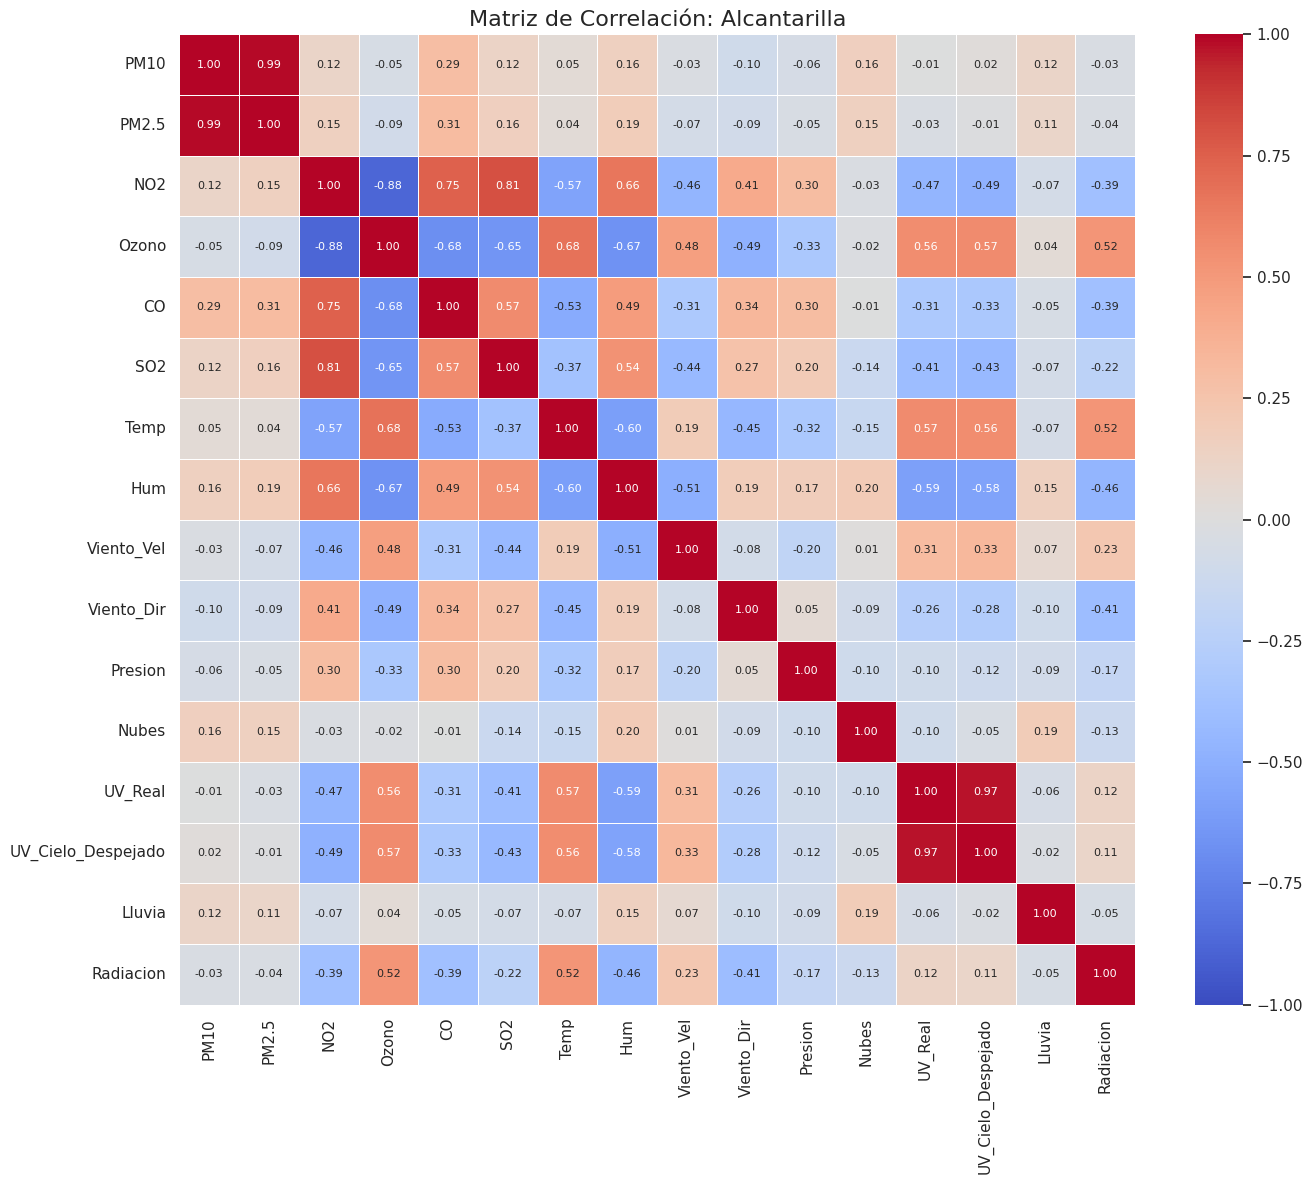

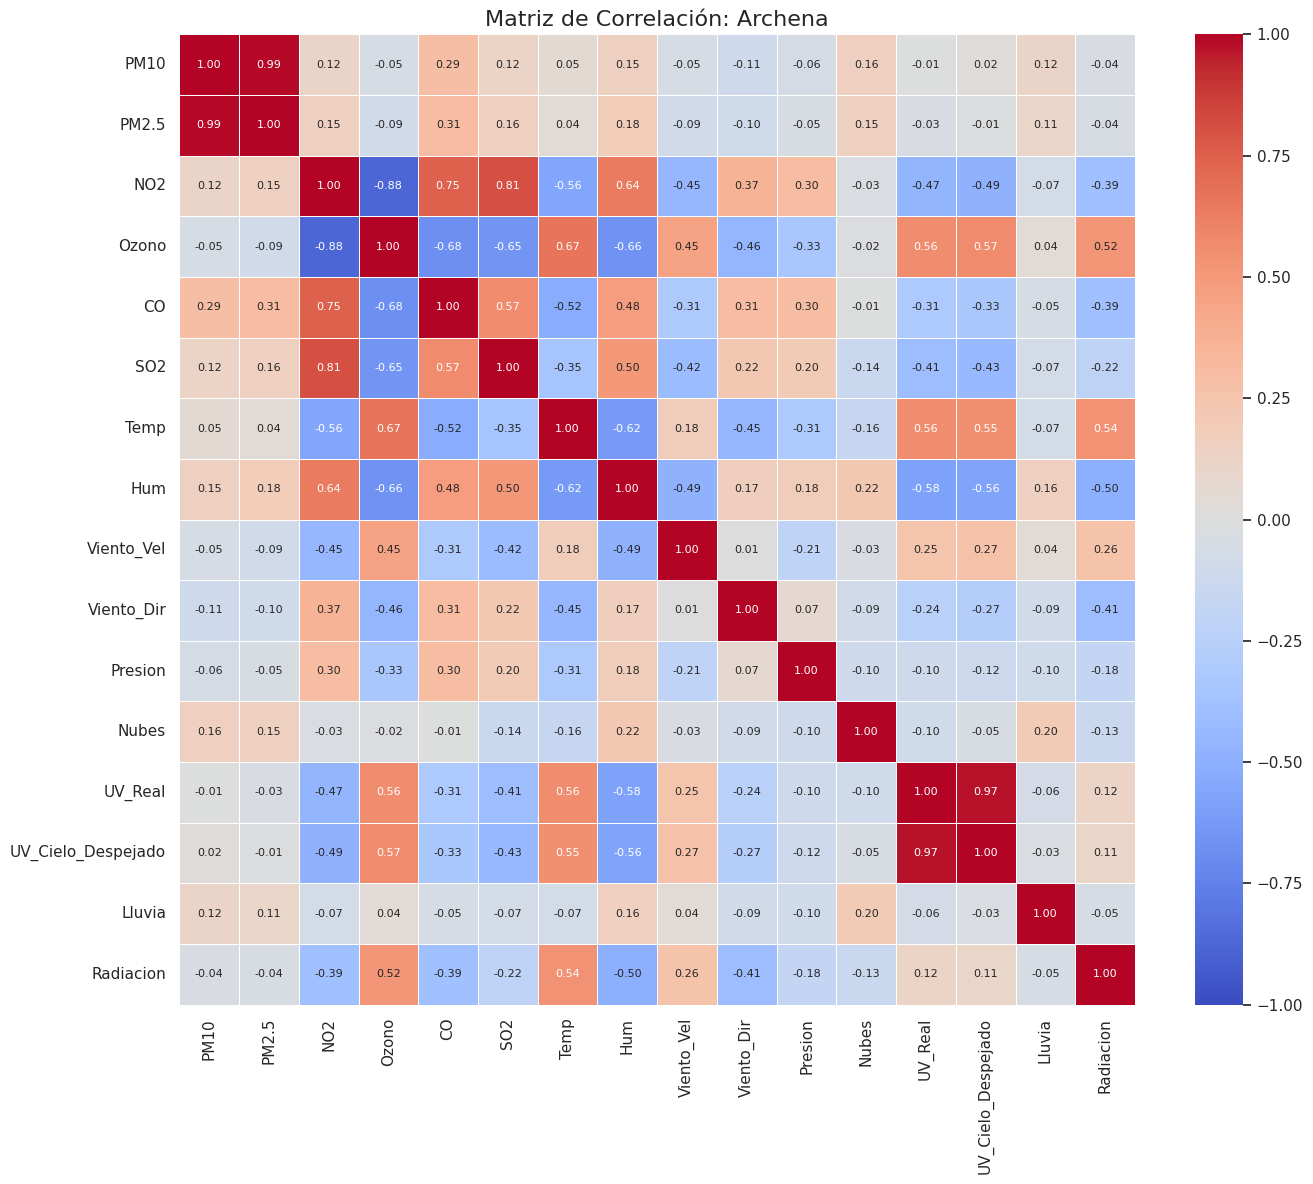

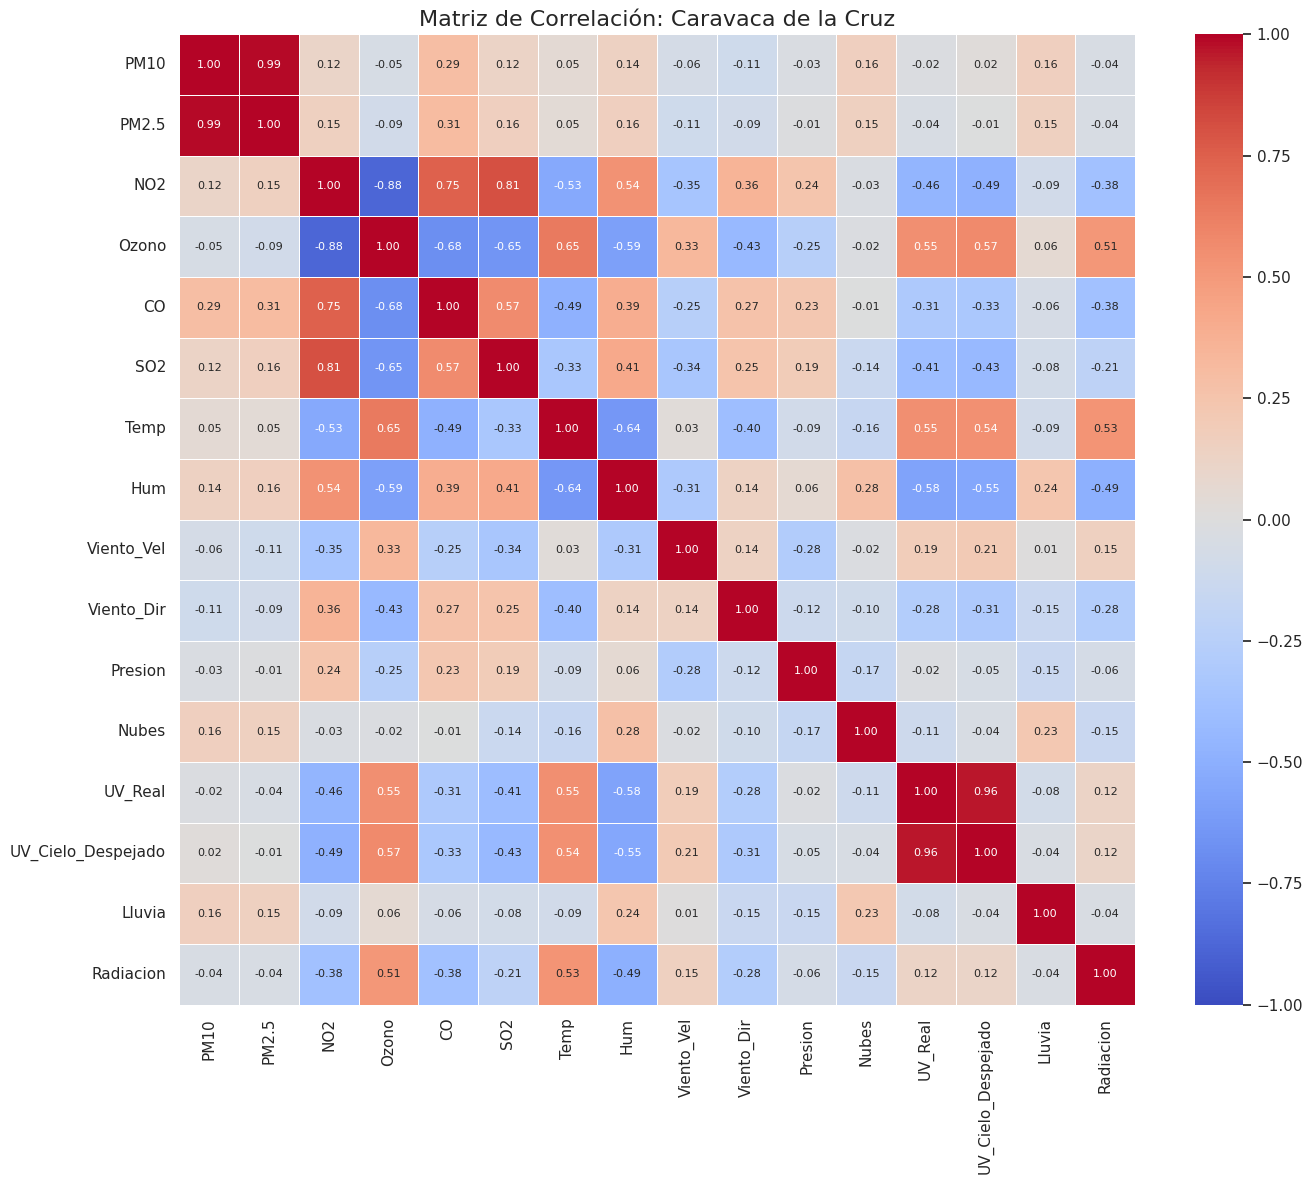

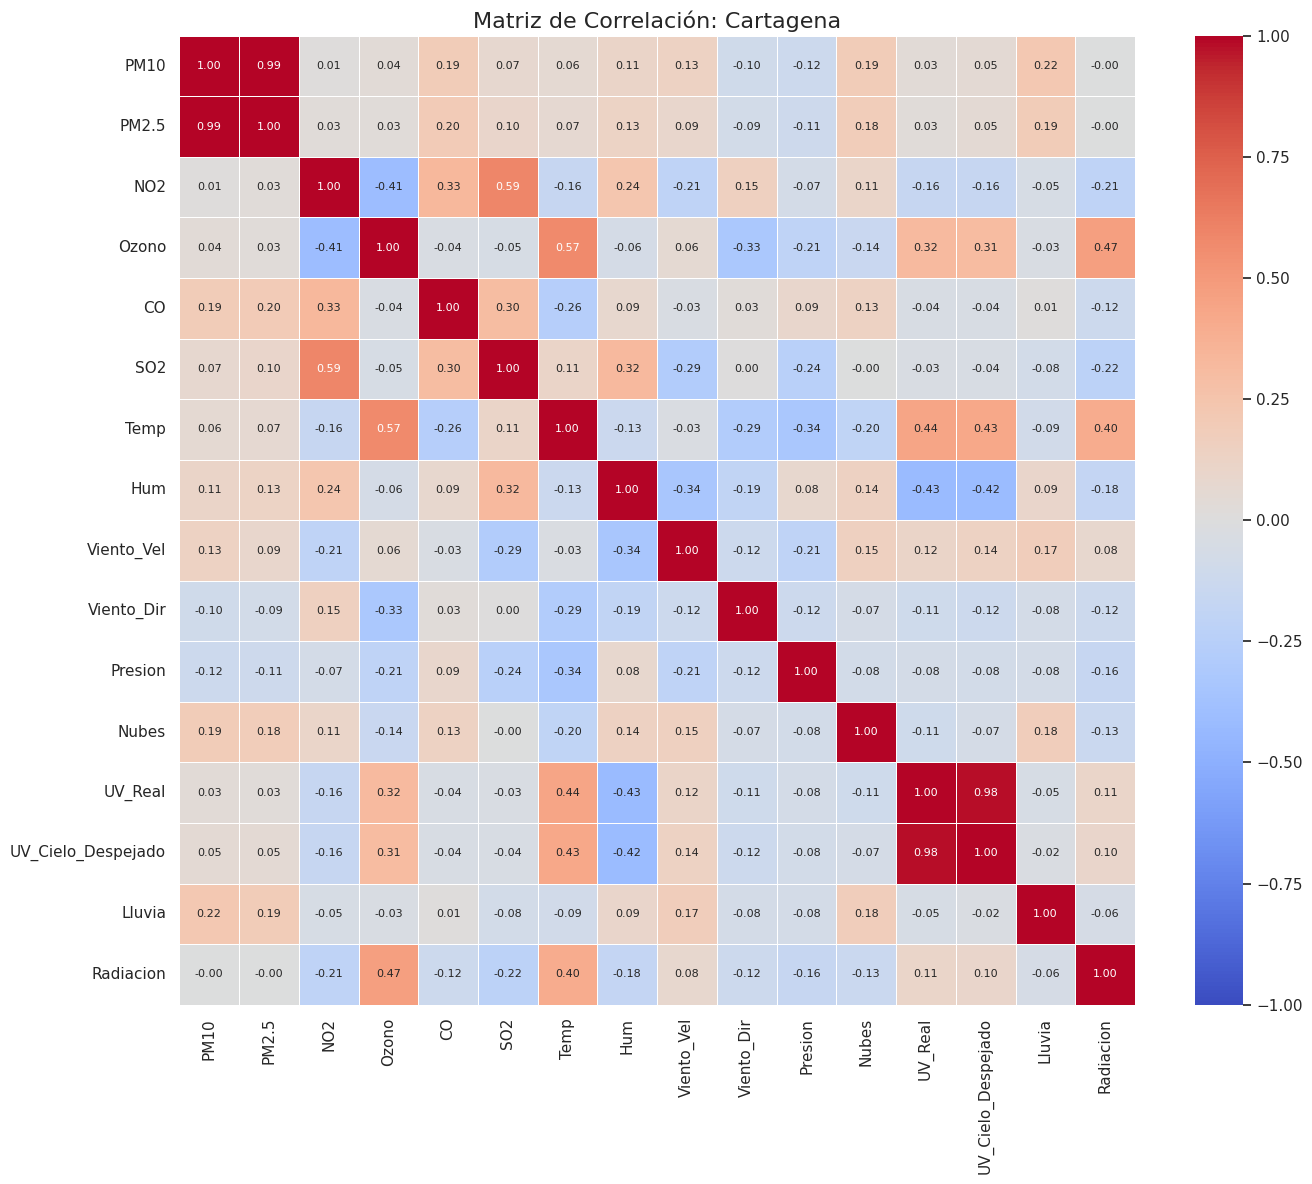

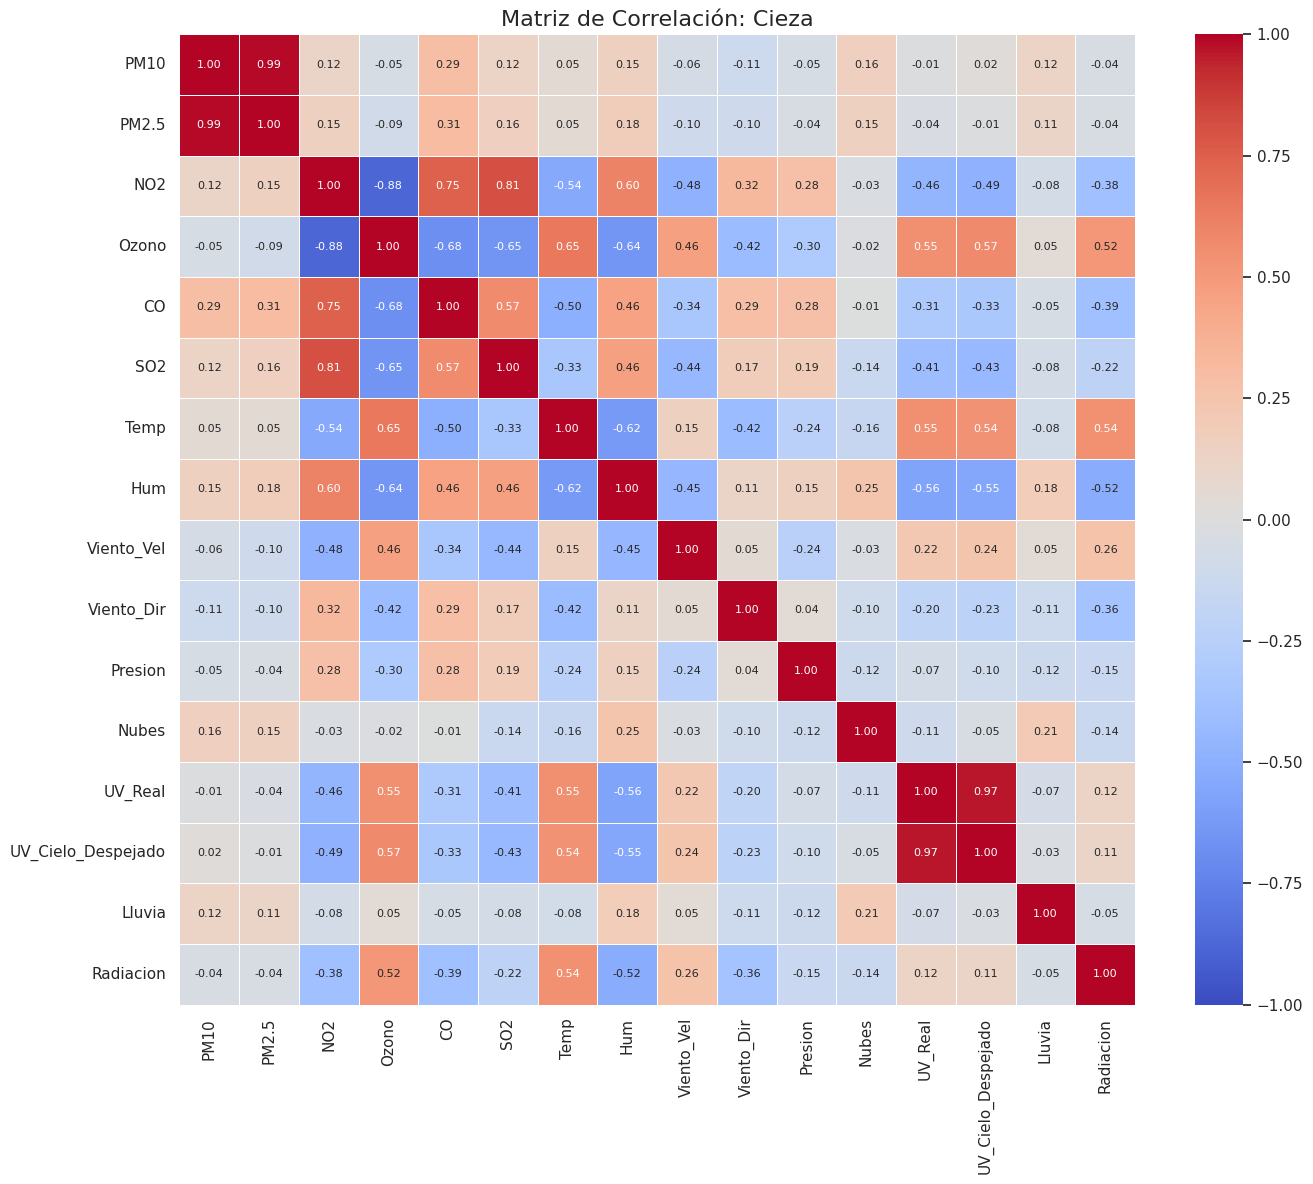

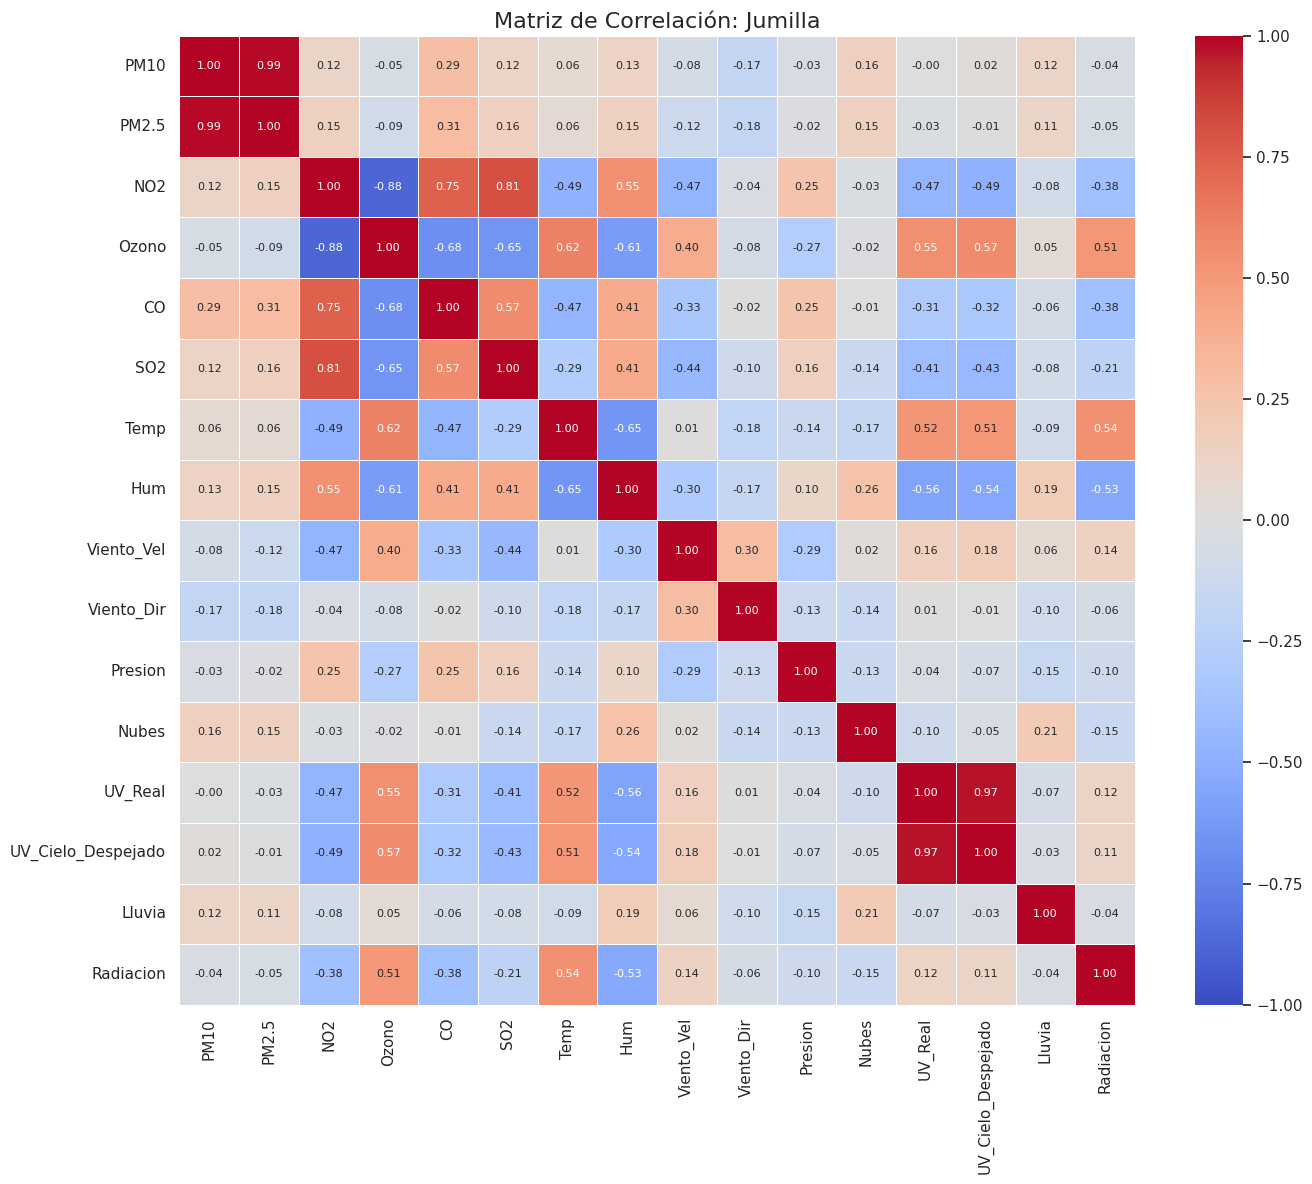

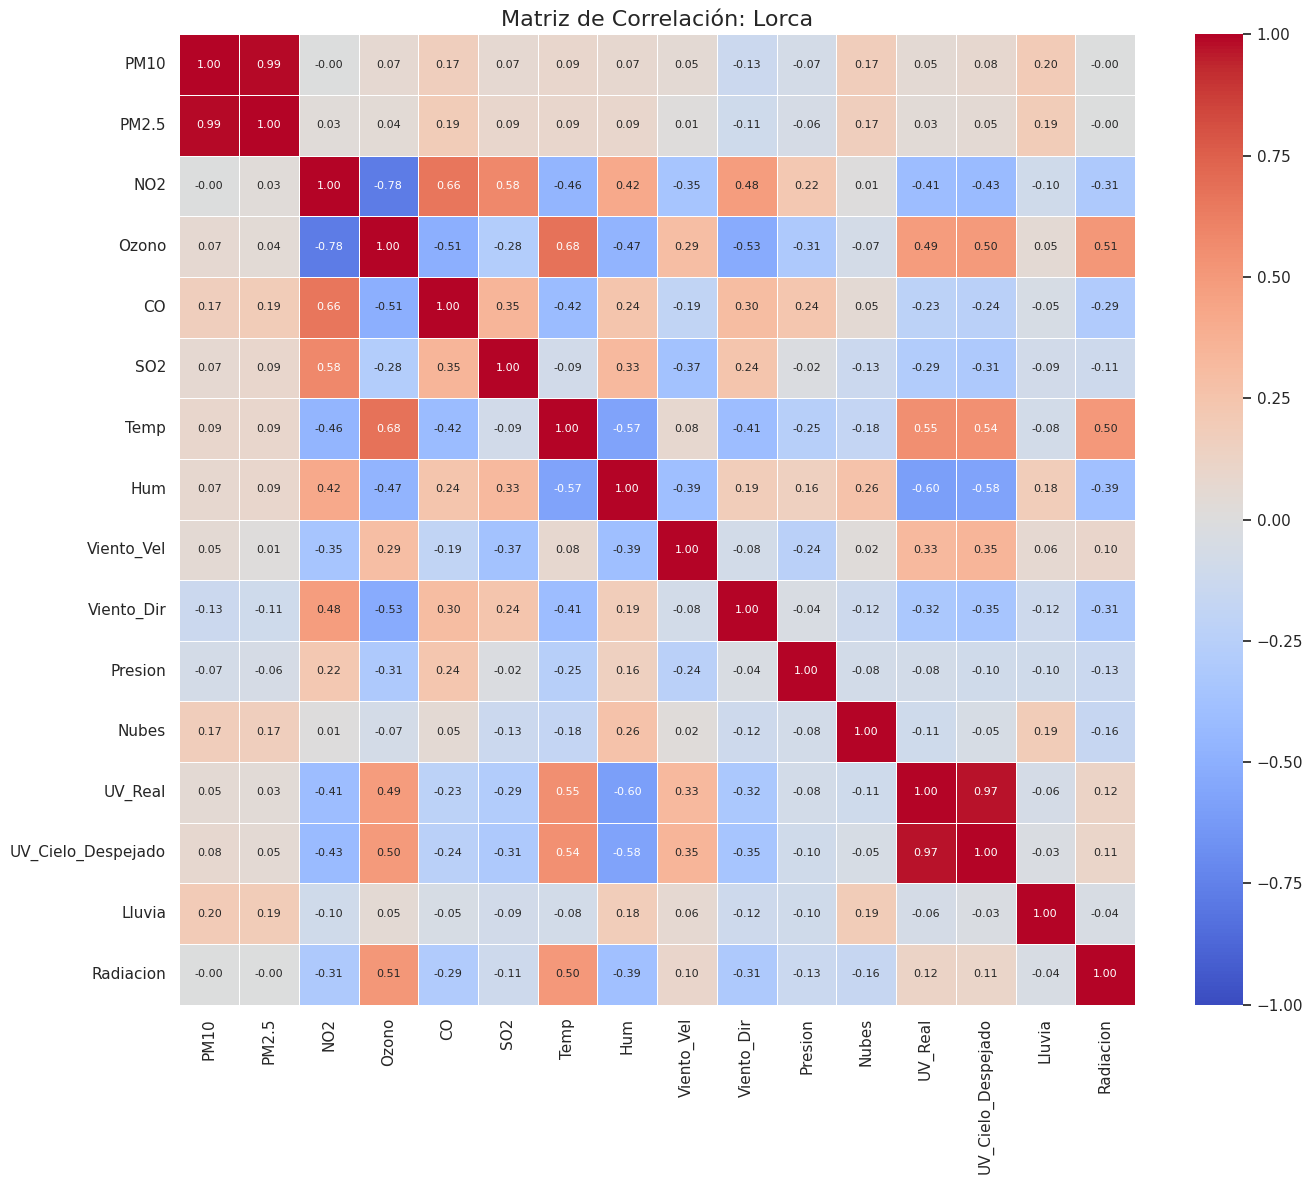

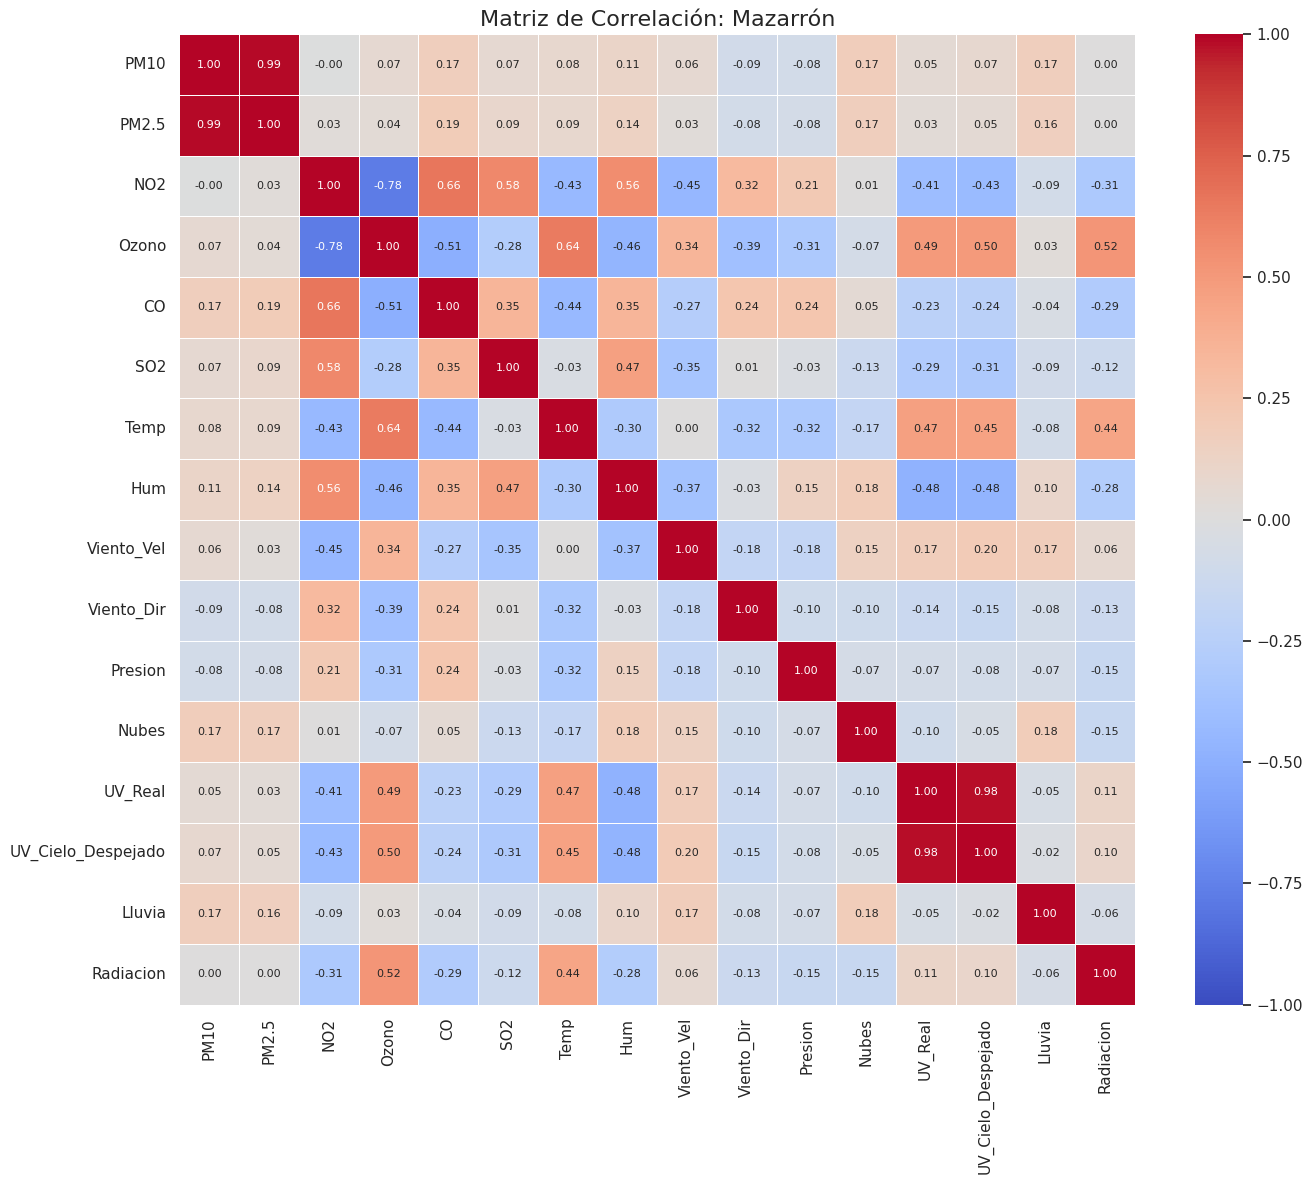

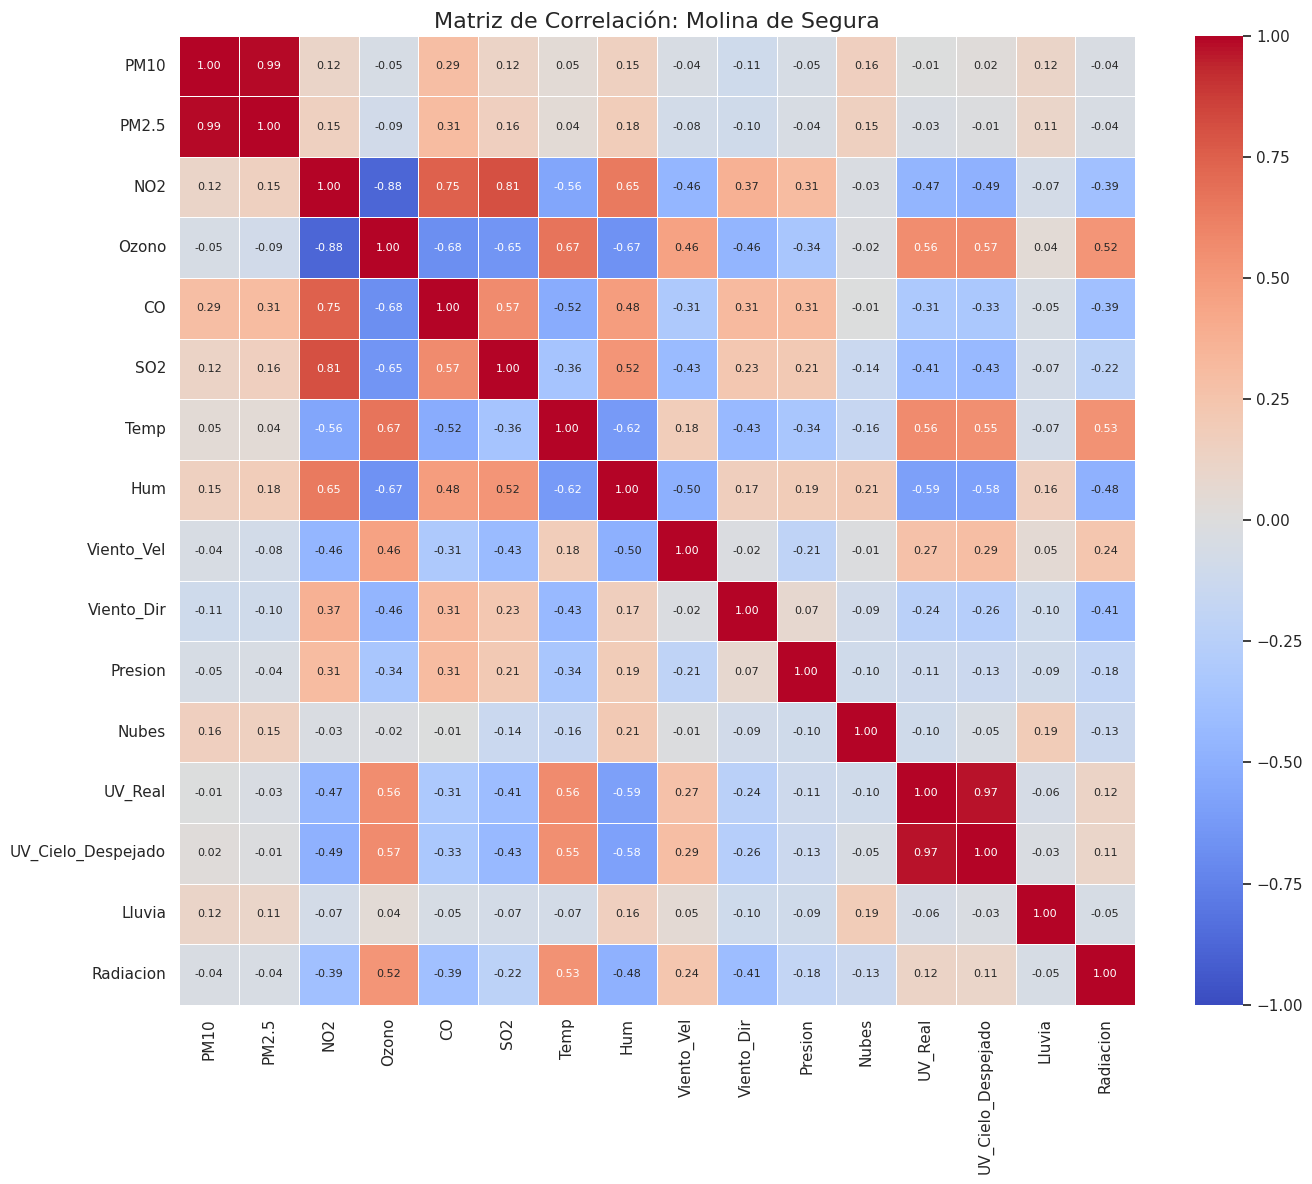

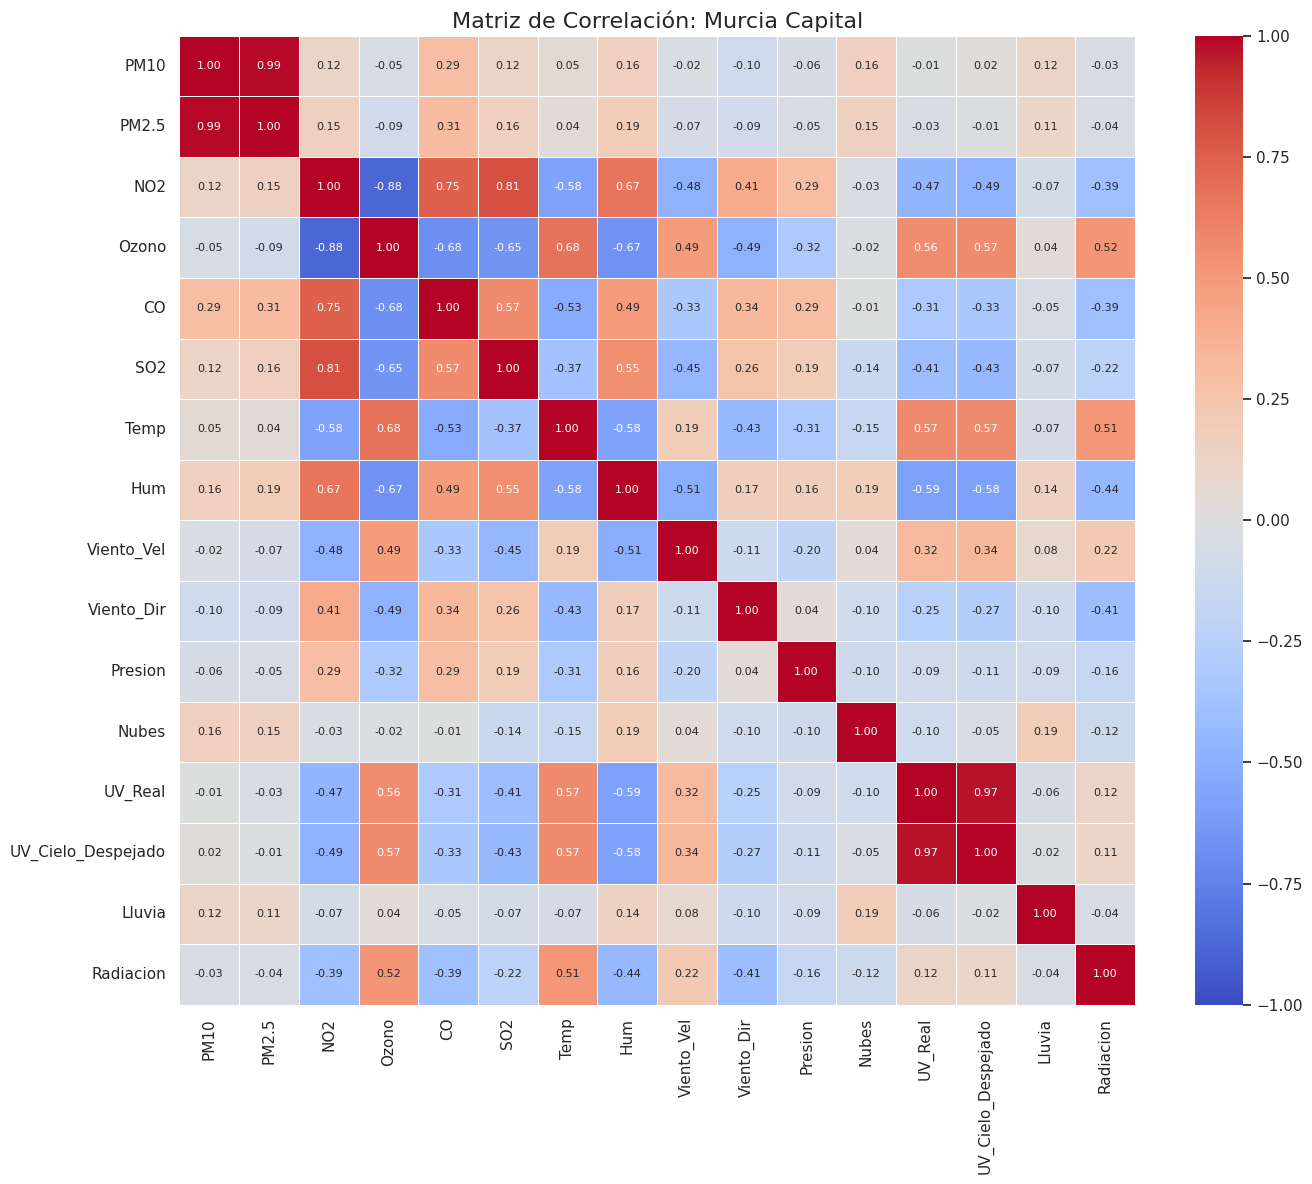

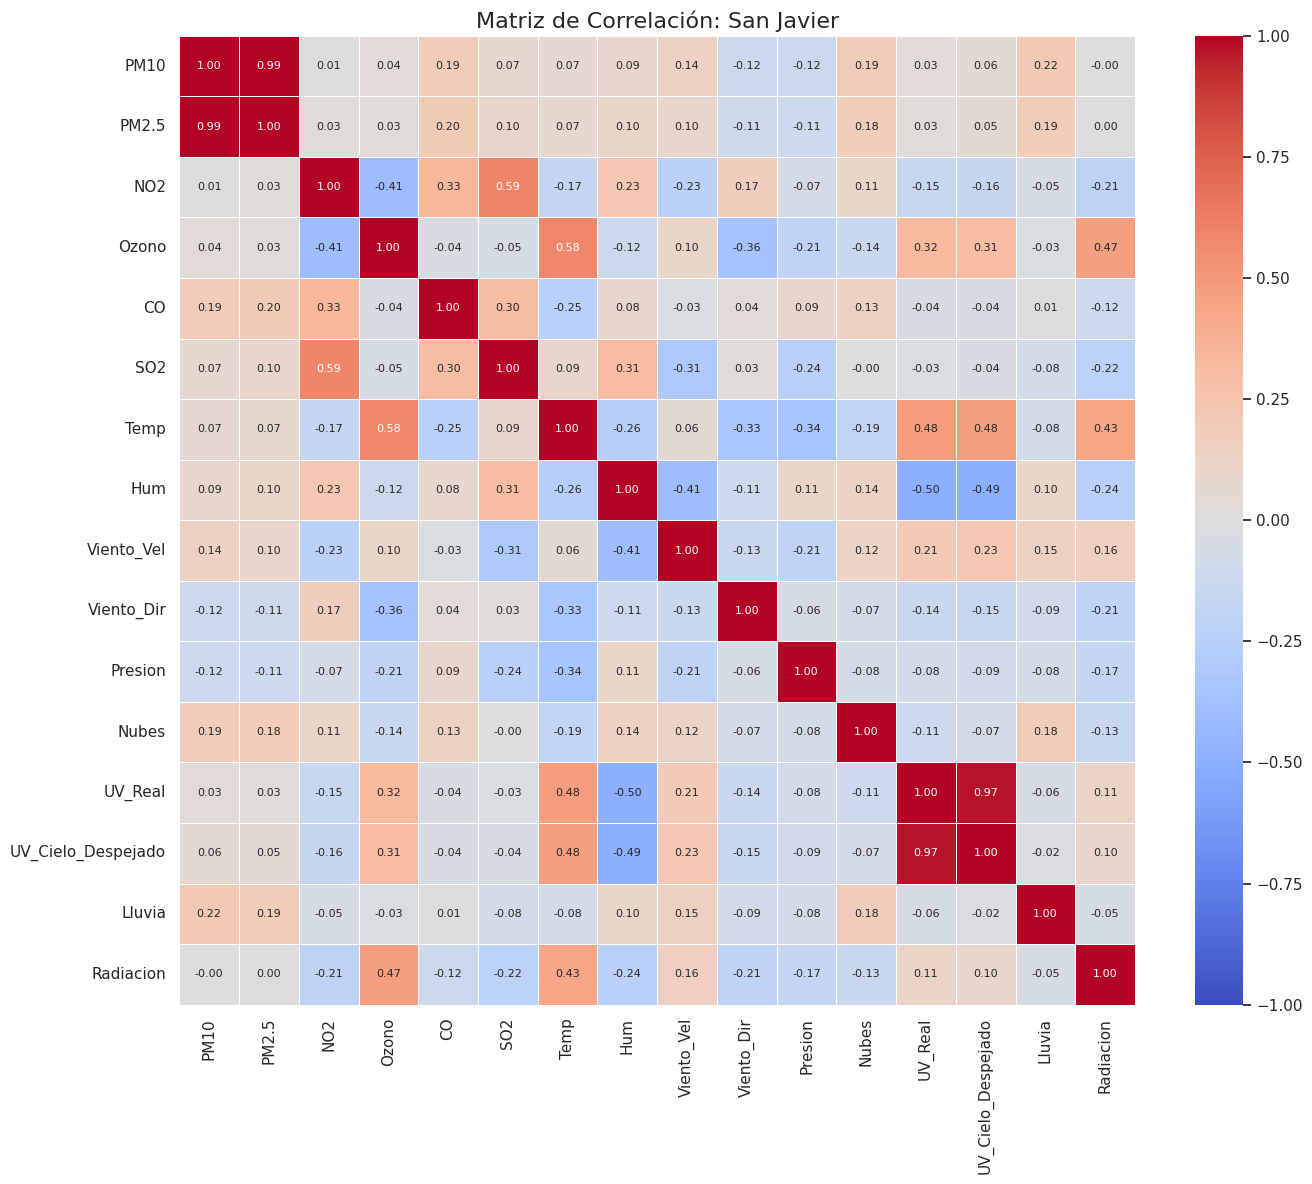

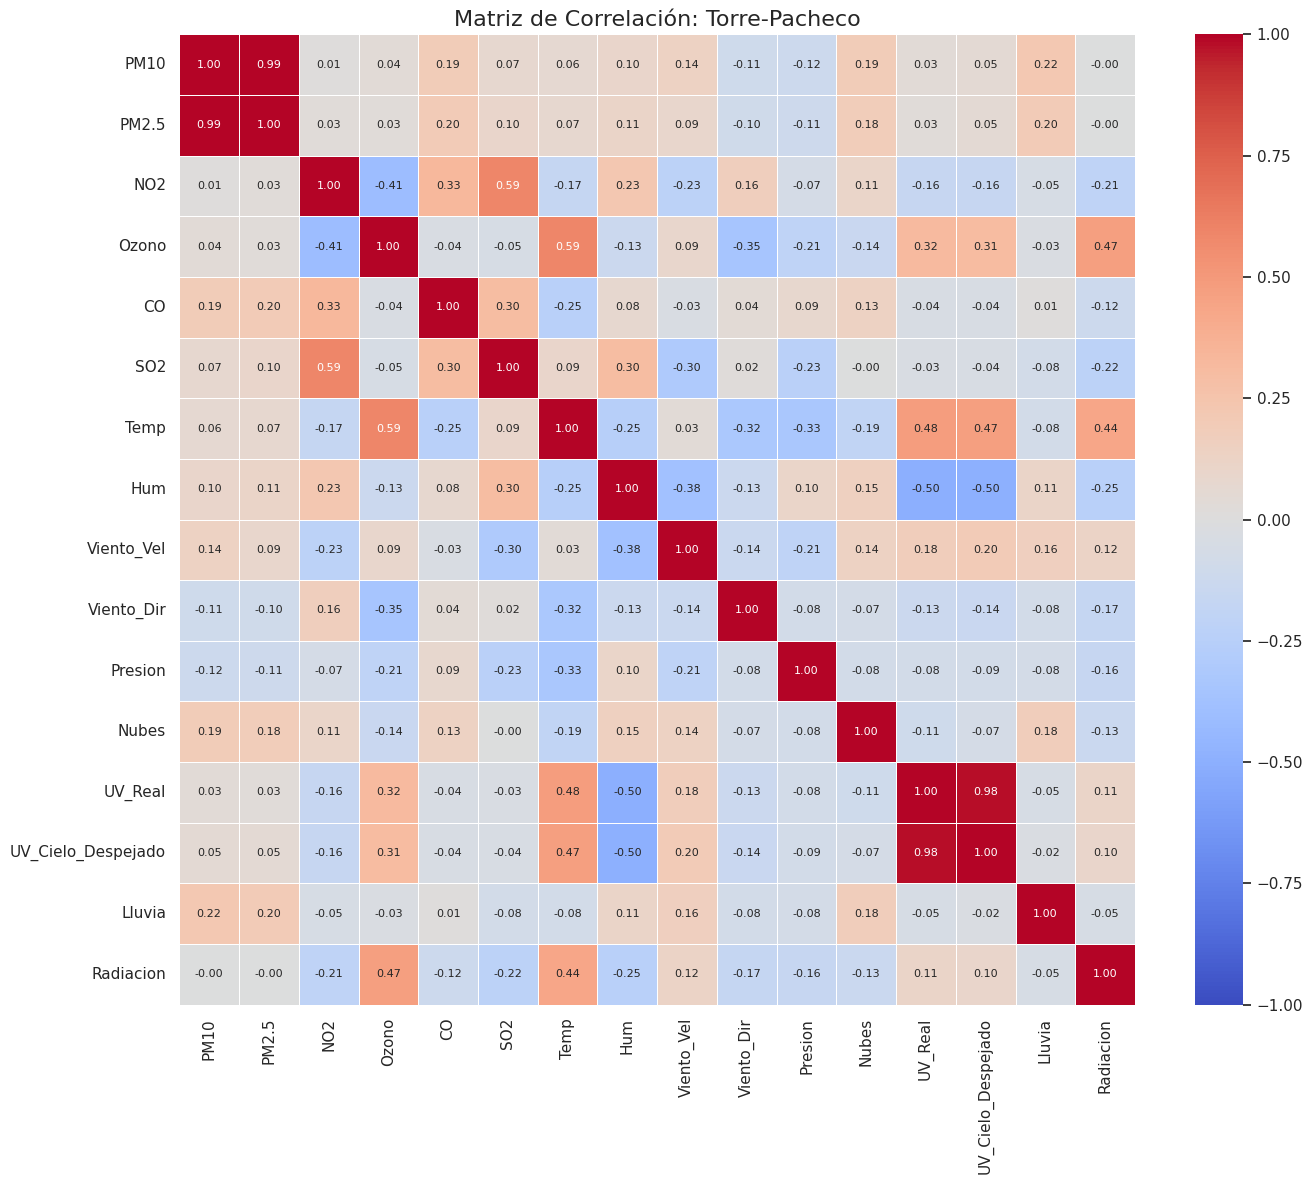

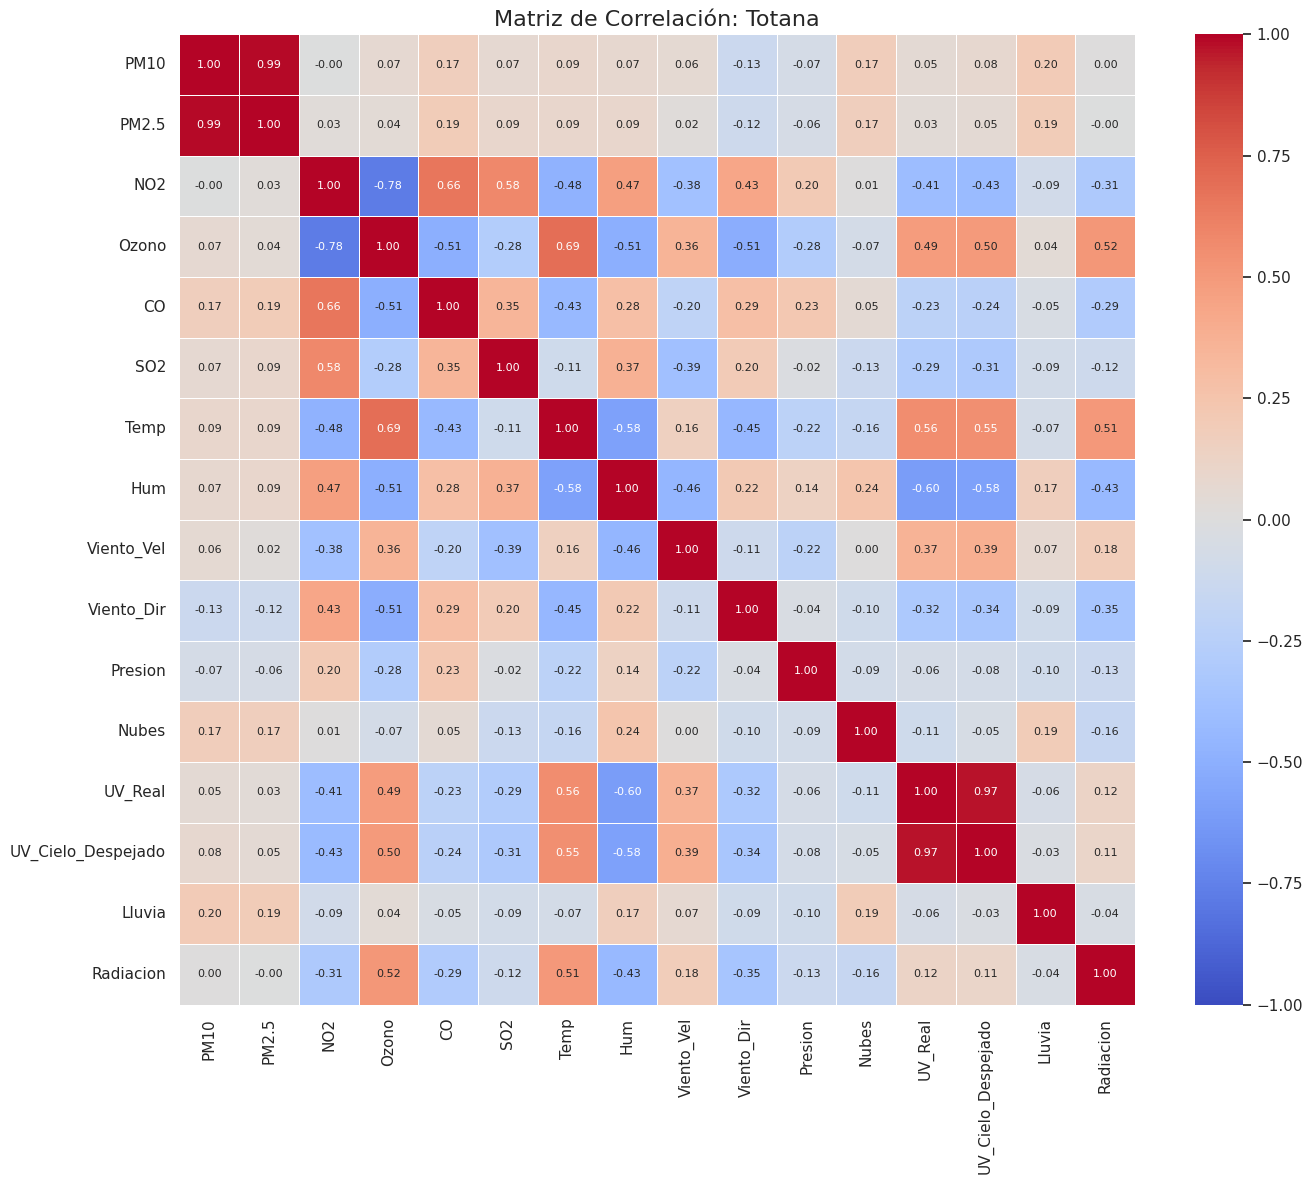

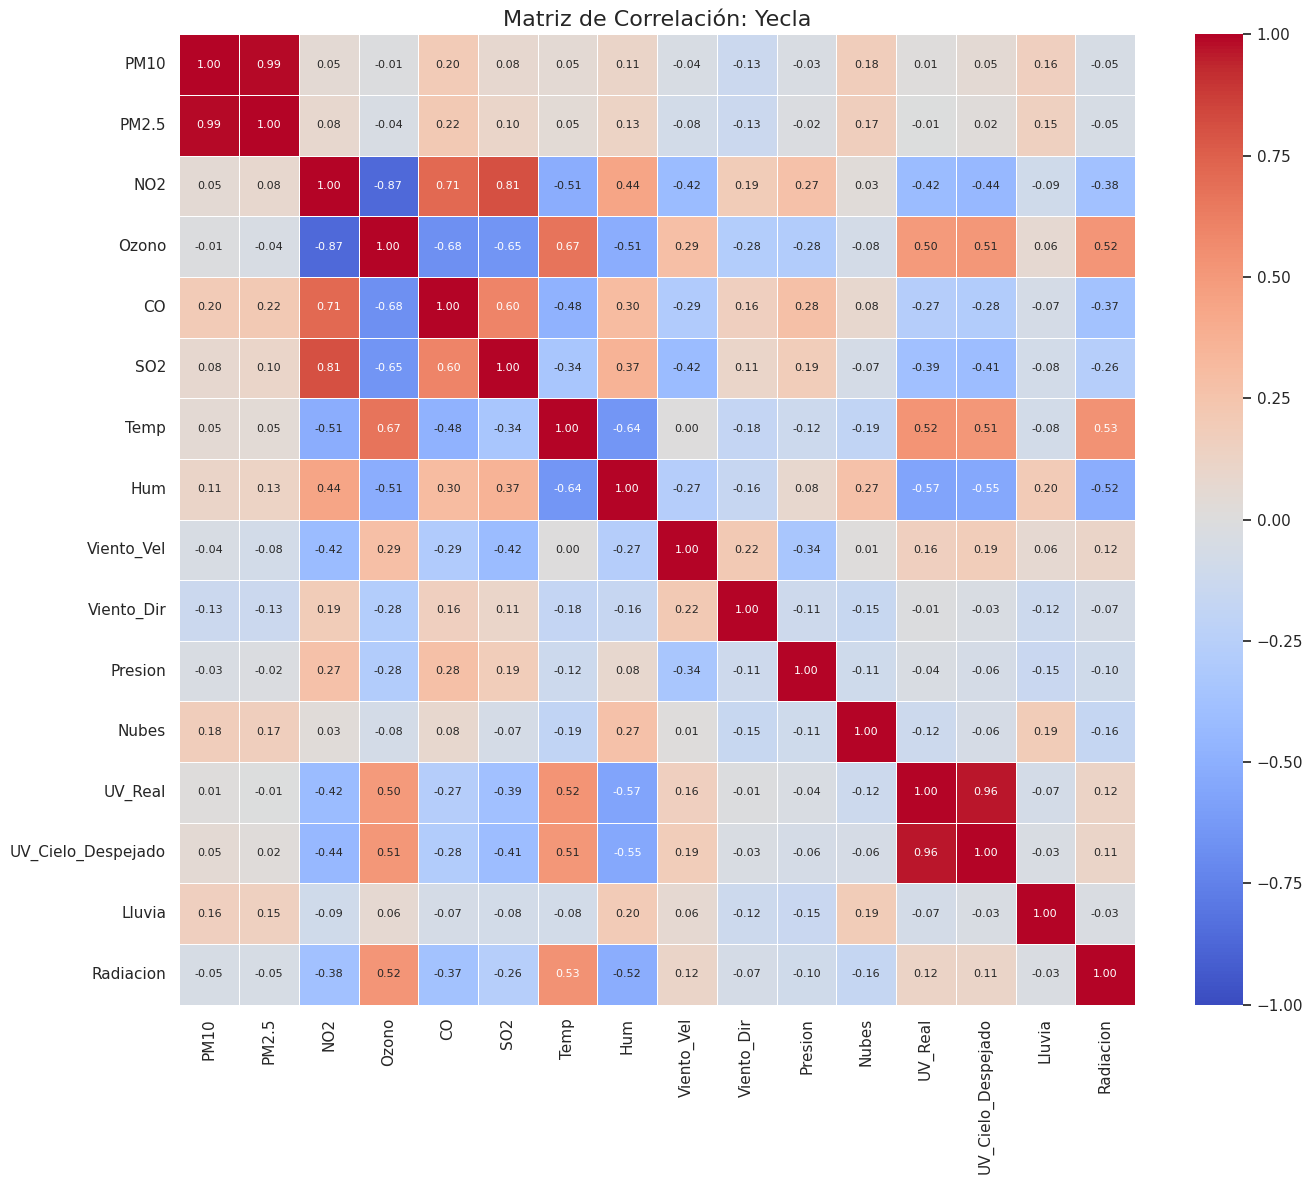

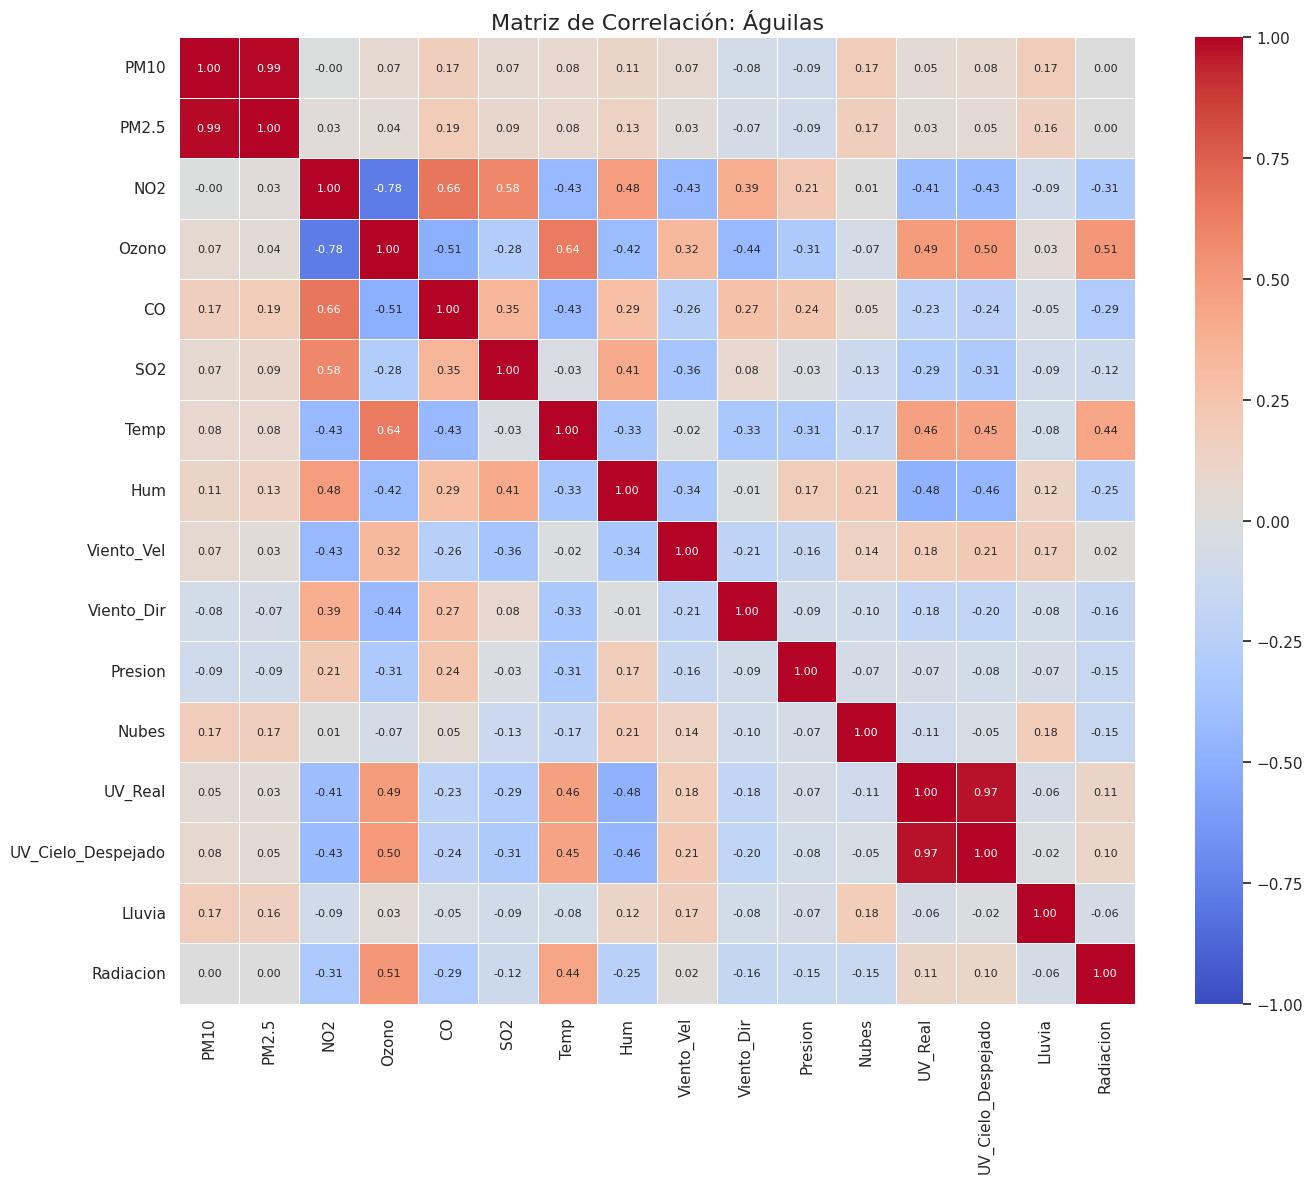

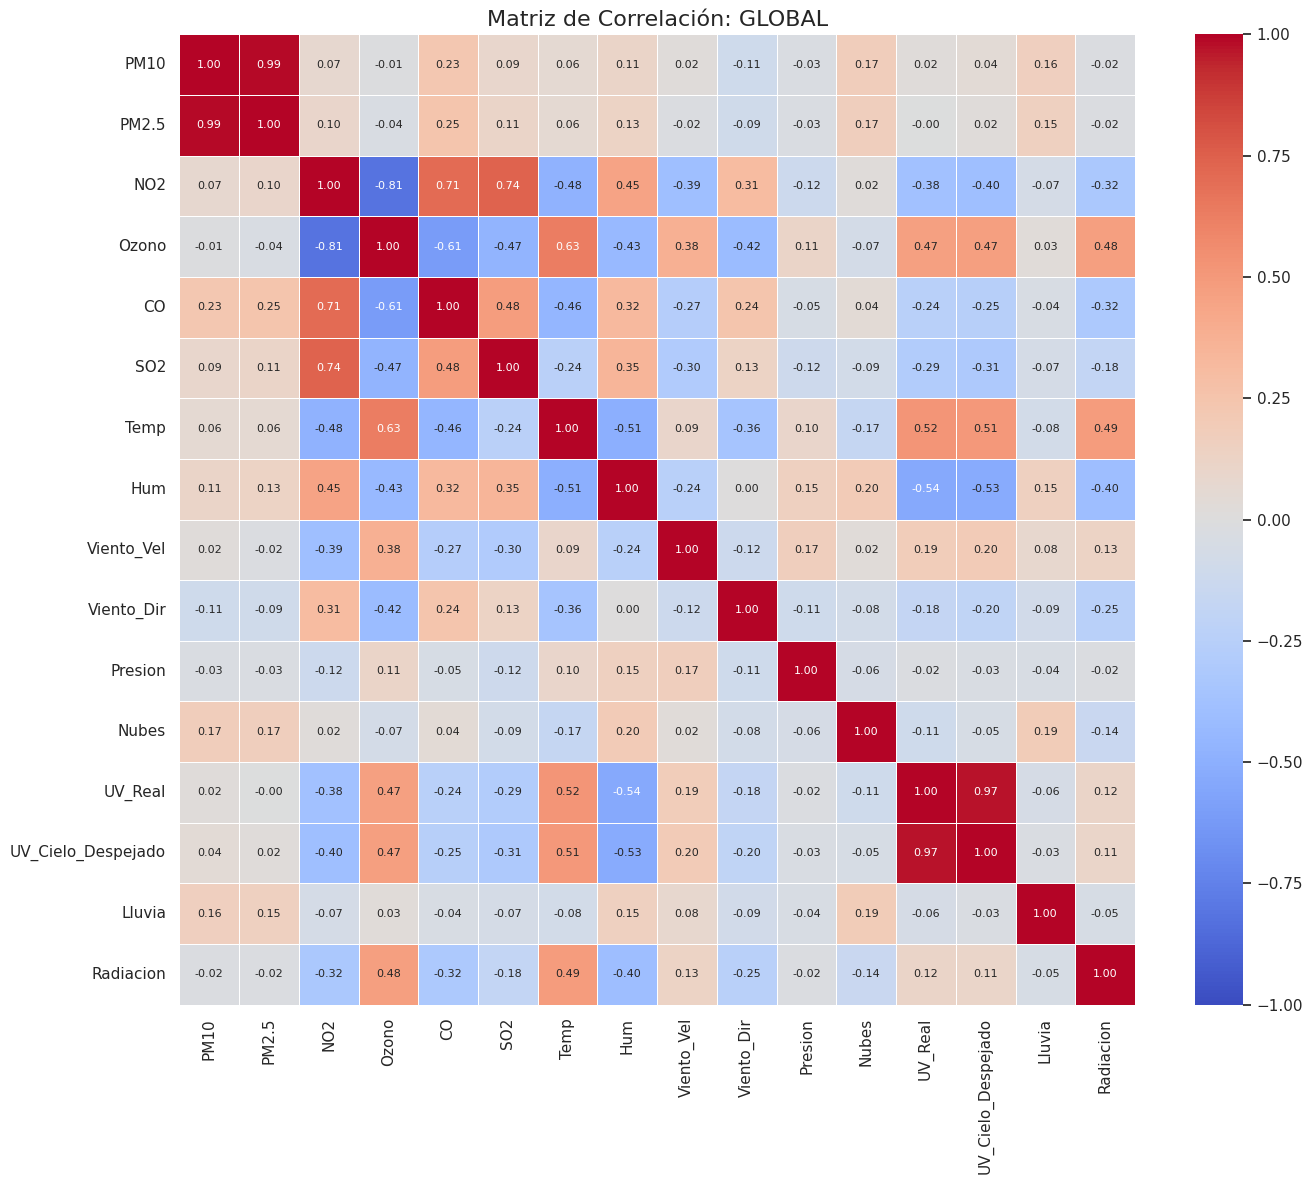

✅ Análisis global finalizado. Gráficos listos en: /content/drive/MyDrive/TFM_Profesorado/Graficas_TFM


In [4]:
# ==============================================================================
# BLOQUE MAESTRO: Carga de Datos y Verificación de Entorno
# ==============================================================================
import pandas as pd
import numpy as np
import os, joblib, seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from scipy import stats
from sklearn.preprocessing import StandardScaler
from google.colab import drive

# 1. Montar drive si no está montado
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

PATH_BASE = "/content/drive/MyDrive/TFM_Profesorado/"
RUTA_OUTPUT = os.path.join(PATH_BASE, "Modelos_IA_Listos")
RUTA_GRAPHS = os.path.join(PATH_BASE, "Graficas_TFM")
os.makedirs(RUTA_OUTPUT, exist_ok=True)
os.makedirs(RUTA_GRAPHS, exist_ok=True)

# 2. Carga segura del dataset (solo si no está en memoria)
if 'df' not in globals():
    print("🔄 Cargando dataset desde el Drive...")
    df = pd.read_parquet(f"{PATH_BASE}Murcia_Dataset_Completo_Global_3H.parquet")
    df['time'] = pd.to_datetime(df['time'])
    df['anio'] = df['time'].dt.year
    df['mes'] = df['time'].dt.month
    features = ['PM10', 'PM2.5', 'NO2', 'Ozono', 'CO', 'SO2', 'Temp', 'Hum',
                'Viento_Vel', 'Viento_Dir', 'Presion', 'Nubes', 'UV_Real',
                'UV_Cielo_Despejado', 'Lluvia', 'Radiacion']
    estaciones = list(df['Estacion'].unique()) + ['GLOBAL']
    print(f"✅ Datos cargados correctamente. Registros: {df.shape[0]}")

# ==============================================================================
# 3. ANÁLISIS DE CORRELACIÓN MULTIVARIANTE (Automático)
# ==============================================================================
print(f"🚀 Generando {len(estaciones)} mapas de calor...")

for est in estaciones:
    # Filtro dinámico
    subset = df[df['Estacion'] == est].copy() if est != 'GLOBAL' else df.copy()

    # Matriz y gráfico
    plt.figure(figsize=(14, 12))
    corr = subset[features].corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f",
                vmin=-1, vmax=1, square=False, linewidths=0.5, annot_kws={"size": 8})

    plt.title(f"Matriz de Correlación: {est}", fontsize=16)
    plt.tight_layout()

    # Guardar en Drive
    filepath = os.path.join(RUTA_GRAPHS, f"heatmap_{est.replace(' ', '_')}.png")
    plt.savefig(filepath, dpi=300)
    plt.show()
    plt.close()

print(f"✅ Análisis global finalizado. Gráficos listos en: {RUTA_GRAPHS}")